In [41]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
from sklearn.preprocessing import PolynomialFeatures

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [42]:
df=pd.read_csv("/content/drive/My Drive/Colab Notebooks/Machine Learning/Ice_cream selling data.csv")
print("Dataset loaded successfully")

Dataset loaded successfully


In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49 entries, 0 to 48
Data columns (total 2 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Temperature (°C)         49 non-null     float64
 1   Ice Cream Sales (units)  49 non-null     float64
dtypes: float64(2)
memory usage: 916.0 bytes


In [44]:
df.shape

(49, 2)

In [46]:
df.describe()

,Temperature (°C),Ice Cream Sales (units)
count,49.000000,49.000000
mean,0.271755,15.905308
std,2.697672,12.264682
min,-4.662263,0.328626
25%,-2.111870,4.857988
50%,0.688781,12.615181
75%,2.784836,25.142082
max,4.899032,41.842986


In [47]:
df.isnull().sum()

,0
Temperature (°C),0
Ice Cream Sales (units),0


In [48]:
print("Number of duplicate records: ",df.duplicated().sum())

Number of duplicate records:  0


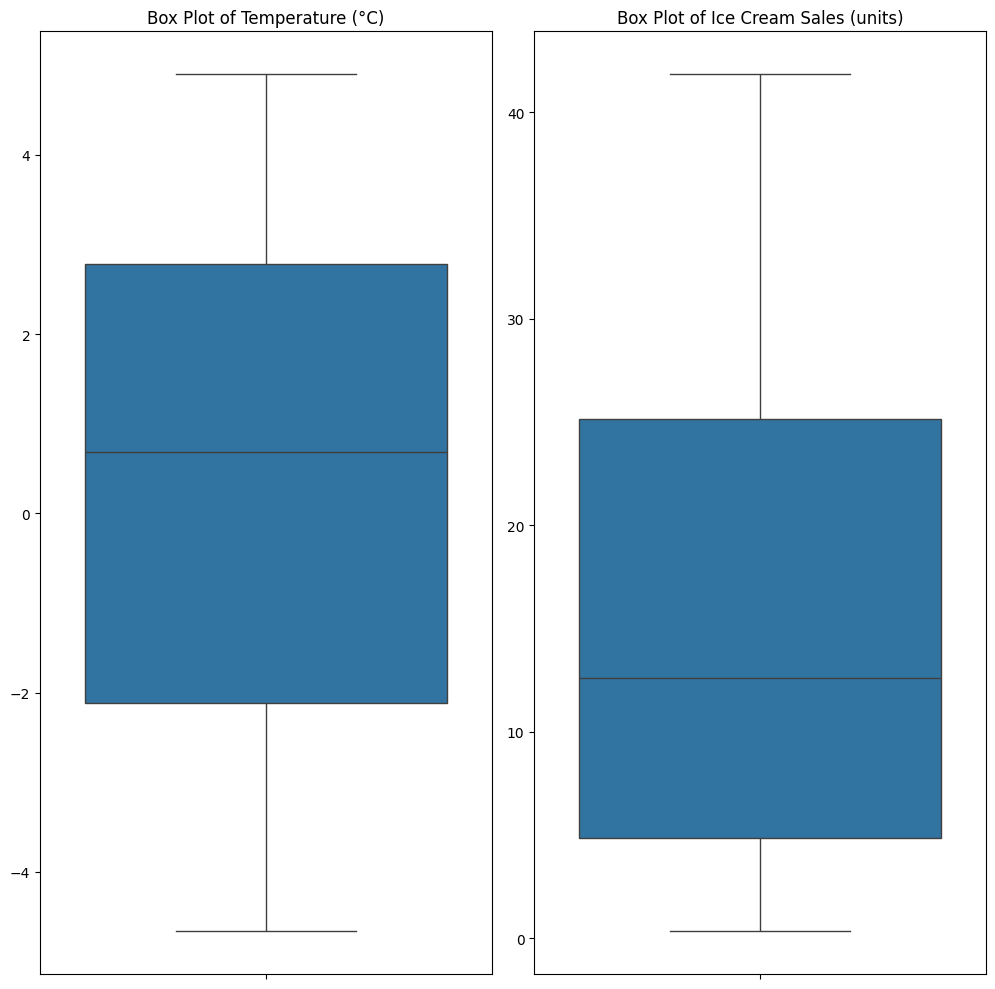

In [49]:
numerical_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(15, 10))
for i, column in enumerate(numerical_cols, 1):
    plt.subplot(len(numerical_cols) // 3 + 1, 3, i)
    sns.boxplot(y=df[column])
    plt.title(f'Box Plot of {column}')
    plt.ylabel('')
plt.tight_layout()
plt.show()


In [50]:
x=df.iloc[:,:-1]
print("Splitting of independent variable done successfully")
y=df.iloc[:,-1]
print("Splitting of dependent variable done successfully")

Splitting of independent variable done successfully
Splitting of dependent variable done successfully


In [52]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
print("Data Splitted Successfully")

Data Splitted Successfully


In [51]:
print(f"Number of instances for training: {len(x_train)}")
print(f"Number of instances for testing: {len(x_test)}")

Number of instances for training: 39
Number of instances for testing: 10


In [68]:
poly_features=PolynomialFeatures(degree=2)
x_train_poly = poly_features.fit_transform(x_train)

In [69]:
lr_model=LinearRegression()
lr_model.fit(x_train_poly,y_train)

LinearRegression()

In [70]:
model.fit(x_train_poly, y_train)
print("Model Trained Successfully")

Model Trained Successfully


In [72]:
x_test_poly = poly_features.transform(x_test)
y_pred = lr_model.predict(x_test_poly)
df=pd.DataFrame({'Actual':y_test,'Predicted':y_pred})
print(df)

       Actual  Predicted
13  10.012868  10.244999
45  17.843957  25.828077
47  27.698383  31.824104
44  28.912188  24.617042
17   9.392969   4.433803
27   2.313806   4.007857
26   0.789974   3.582775
25   4.625689   3.178651
31   4.857988   7.869905
19   4.673643   2.915914


In [73]:
# Evaluate model performance on training data using MAE, MSE, RMSE, and R2 score
y_train_pred = model.predict(x_train_poly)
mae = mean_absolute_error(y_train, y_train_pred)
mse = mean_squared_error(y_train, y_train_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_train, y_train_pred)
print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root MSE (RMSE):", rmse)
print("R2 Score:", r2)

Mean Absolute Error (MAE): 2.5993732834161136
Mean Squared Error (MSE): 8.995867597495232
Root MSE (RMSE): 2.99931118717202
R2 Score: 0.9413665676490518


In [76]:
# Evaluate model performance on testing data using MAE, MSE, RMSE, and R2 score
x_test_poly = poly_features.transform(x_test)
y_test_pred = model.predict(x_test_poly)
mae = mean_absolute_error(y_test, y_test_pred)
mse = mean_squared_error(y_test, y_test_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_test_pred)
print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root MSE (RMSE):", rmse)
print("R2 Score: ", r2)

Mean Absolute Error (MAE): 3.2299819836597274
Mean Squared Error (MSE): 14.878796440981484
Root MSE (RMSE): 3.857304297171988
R2 Score:  0.843055137193884


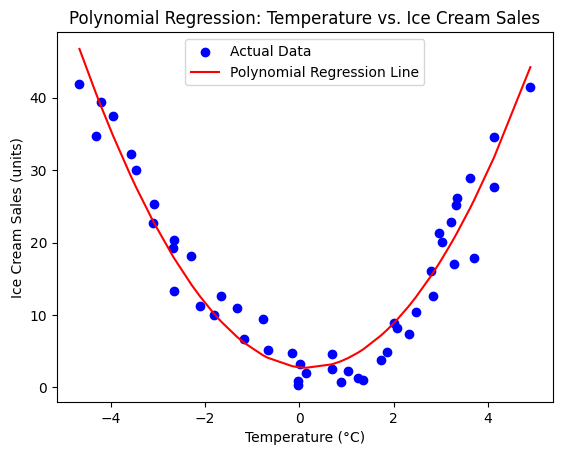

In [78]:
plt.scatter(x, y, color='blue', label='Actual Data')
plt.plot(x, model.predict(poly_features.transform(x)), color='red', label='Polynomial Regression Line')
plt.xlabel('Temperature (°C)')
plt.ylabel('Ice Cream Sales (units)')
plt.title('Polynomial Regression: Temperature vs. Ice Cream Sales')
plt.legend()
plt.show()